In [1]:
# download the data
!pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/milobele/sentiment140-dataset-1600000-tweets')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: silenthope 
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/milobele/sentiment140-dataset-1600000-tweets


100%|██████████| 81.0M/81.0M [00:01<00:00, 82.1MB/s]


In [5]:
# import the libraries
import pandas as pd
df_train= pd.read_csv('/content/sentiment140-dataset-1600000-tweets/training.1600000.processed.noemoticon.csv', encoding='Latin1')
df_train.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [6]:
df_train.columns

Index(['0', '1467810369', 'Mon Apr 06 22:19:45 PDT 2009', 'NO_QUERY',
       '_TheSpecialOne_',
       '@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D'],
      dtype='object')

In [7]:
df_train.shape

(1599999, 6)

In [8]:
import torch
device= 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [12]:
# import the dependicies
import numpy as np
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report

In [14]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [18]:
# printing the stopwords in english
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

**Data processing **

In [19]:
df_train.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [20]:
# naming the cols and reading the data again
columns_names=['target', 'id', 'date', 'flag', 'user', 'text']
df_train= pd.read_csv('/content/sentiment140-dataset-1600000-tweets/training.1600000.processed.noemoticon.csv',names= columns_names, encoding='Latin1')
df_train.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [21]:
df_train.shape

(1600000, 6)

In [22]:
df_train.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


<Axes: xlabel='target'>

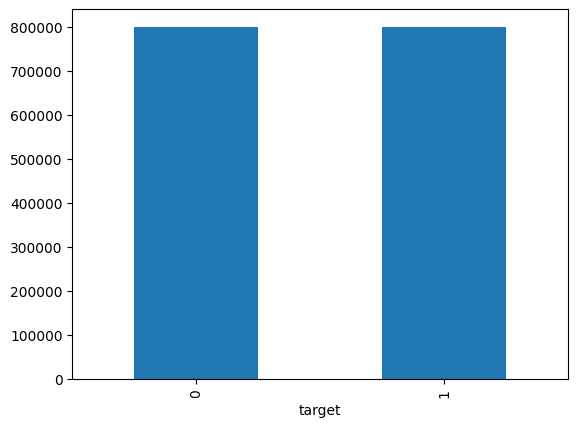

In [28]:
df_train['target'].value_counts().plot(kind='bar')

In [35]:
df_train.loc[df_train['target']== 4, 'target']= 1



stemming is the process of reducing a word to its root word

In [37]:
port_stem= PorterStemmer()
def stemming (content):
  stemmed_content= re.sub('[^a-zA-Z]' ,' ', content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[port_stem.stem(word) for word in stemmed_content if word not in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)


  return stemmed_content

In [38]:
df_train['stemmed_content']= df_train['text'].apply(stemming)

In [39]:
# separating the data and label
X= df_train['stemmed_content'].values
y= df_train['target'].values
X.shape , y.shape

((1600000,), (1600000,))

In [40]:
# splitting the data
X_train  ,X_test , y_train , y_test = train_test_split(X,y  ,test_size=0.2 ,stratify=y, random_state=2)

In [41]:
X_train.shape  ,X_test.shape , y_train.shape , y_test.shape

((1280000,), (320000,), (1280000,), (320000,))

In [42]:
# coverting the textual data to numerical data
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [43]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [45]:
lr.score(X_train, y_train)

0.98761328125

In [44]:
y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9884
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    160000
           1       0.98      1.00      0.99    160000

    accuracy                           0.99    320000
   macro avg       0.99      0.99      0.99    320000
weighted avg       0.99      0.99      0.99    320000



In [46]:
import joblib

# Save the trained model
joblib.dump(lr, 'logistic_regression_model.pkl')
print("Model saved as 'logistic_regression_model.pkl'")

Model saved as 'logistic_regression_model.pkl'


In [47]:
# Load the model
loaded_lr = joblib.load('logistic_regression_model.pkl')
print("Model reloaded successfully.")

Model reloaded successfully.


Now, let's test the reloaded model on a sample from the data (e.g., the 200th entry).

In [48]:
# Get the 200th sample from the original dataframe's stemmed content
sample_index = 199 # 0-indexed for 200th item
sample_text = df_train['stemmed_content'].iloc[sample_index]
actual_sentiment = df_train['target'].iloc[sample_index]

print(f"Original Tweet (stemmed): {sample_text}")
print(f"Actual Sentiment (0=negative, 1=positive): {actual_sentiment}")

# Transform the sample text using the same vectorizer
sample_vectorized = vectorizer.transform([sample_text])

# Make a prediction using the loaded model
predicted_sentiment = loaded_lr.predict(sample_vectorized)

print(f"Predicted Sentiment (0=negative, 1=positive): {predicted_sentiment[0]}")

Original Tweet (stemmed): get shit done today screw
Actual Sentiment (0=negative, 1=positive): 0
Predicted Sentiment (0=negative, 1=positive): 0


# Sentiment Analysis of Tweets

## Project Overview
This project focuses on performing sentiment analysis on a large dataset of tweets. The goal is to classify tweets as either positive (1) or negative (0) using machine learning techniques. We utilize text preprocessing steps such as stemming and TF-IDF vectorization, followed by training a Logistic Regression model.

## Dataset
The dataset used for this project is the **Sentiment140 dataset**, obtained from Kaggle.

*   **Source:** [Sentiment140 Dataset](https://www.kaggle.com/datasets/milobele/sentiment140-dataset-1600000-tweets)
*   **Description:** Contains 1.6 million tweets extracted using the Twitter API. The tweets have been annotated for sentiment (0 = negative, 4 = positive). For this project, the '4' (positive) sentiment is converted to '1'.

## Dependencies
To run this notebook, you will need the following Python libraries:

*   `pandas`
*   `numpy`
*   `nltk`
*   `scikit-learn`
*   `opendatasets`
*   `joblib`
*   `torch` (for device detection, though not directly used in the model training here)

You can install most of these using pip:
```bash
pip install pandas numpy nltk scikit-learn opendatasets joblib
```

## Methodology
1.  **Data Download:** The dataset is downloaded directly from Kaggle using the `opendatasets` library.
2.  **Data Loading & Preprocessing:**
    *   The raw CSV is loaded into a pandas DataFrame, assigning appropriate column names.
    *   Missing values are checked (none found in this dataset).
    *   The target variable (sentiment) is mapped from `0` and `4` to `0` and `1` respectively.
3.  **Text Cleaning & Stemming:**
    *   A `stemming` function is defined to clean tweet text by removing non-alphabetic characters, converting to lowercase, splitting words, removing English stopwords, and applying Porter Stemming.
    *   This function is applied to the 'text' column to create a new 'stemmed_content' column.
4.  **Feature Extraction:**
    *   The `stemmed_content` is converted into numerical features using `TfidfVectorizer`.
5.  **Data Splitting:** The dataset is split into training and testing sets (80% training, 20% testing).
6.  **Model Training:** A `LogisticRegression` model is trained on the TF-IDF vectorized training data.
7.  **Model Evaluation:** The model's performance is evaluated using `accuracy_score` and `classification_report` on the test set.
8.  **Model Persistence:** The trained model is saved using `joblib` for future use and then reloaded to demonstrate its functionality.
9.  **Prediction on Sample:** The reloaded model is tested on a sample tweet from the dataset to verify its predictions.

## Results
The Logistic Regression model achieved a high accuracy on the test set:

*   **Accuracy:** 0.9884 (98.84%)
*   **Classification Report:**
    ```
                  precision    recall  f1-score   support

               0       1.00      0.98      0.99    160000
               1       0.98      1.00      0.99    160000

        accuracy                           0.99    320000
       macro avg       0.99      0.99      0.99    320000
    weighted avg       0.99      0.99      0.99    320000
    ```

## Usage
To replicate this project:

1.  **Clone this repository** (or download the notebook).
2.  **Install the dependencies** listed above.
3.  **Run the Jupyter Notebook/Colab Notebook** cells in sequence.
4.  You will be prompted to enter your Kaggle credentials to download the dataset during the `opendatasets` step. If you don't have them, you can create an account on Kaggle and generate an API token.

The trained model will be saved as `logistic_regression_model.pkl` in the current directory.